# **Imports**

In [1]:
from earthscape.constants import *
from earthscape.utils import *
from earthscape.splits.trainvaltestsplits_utils import *

import os
import glob
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# **Train-Val-Test Splits**

## *Setup*

In [2]:
#######################################
# Setup Directories and Parameters
#######################################

# directory to save split selections (saved for dataset version)
if not os.path.isdir(SPLIT_DIR):
    os.makedirs(SPLIT_DIR)

# list of directories containing in-domain & cross-domain patches (GeoJSONs & areas or labels)
indomain_dirs = [r'../data/warren']
crossdomain_dirs = [r'../data/howevalley', r'../data/sonora']

# parameters for split selection
test_size = 1536
val_size = 768

# seeding...
patch_seed = 111
set_seed(patch_seed)


## *In-domain (Warren County)*

In [3]:
############################
# Select In-domain Splits
############################

# list of paths to in-domain patch GeoJSONs
indomain_patch_paths = [glob.glob(os.path.join(d, '*patches*.geojson'))[0] for d in indomain_dirs]


##### read patches GeoJSONs into single geodataframe
gdf_list = [gpd.read_file(p) for p in indomain_patch_paths]
gdf = pd.concat(gdf_list, ignore_index=True)


##### select test split & all remaining non-overlapping patches
gdf_test, gdf_remaining = select_indpendent_patches(gdf, test_size, seed=patch_seed)


##### select validation split & non-overlapping training split from remaining (above)
gdf_val, gdf_train = select_indpendent_patches(gdf_remaining, val_size, seed=patch_seed)


##### save training, validation, & testing patches...
gdf_train.to_file(f"{SPLIT_DIR}/{STR_VERSION}_train.geojson", driver='GeoJSON')
gdf_val.to_file(f"{SPLIT_DIR}/{STR_VERSION}_val.geojson", driver='GeoJSON')
gdf_test.to_file(f"{SPLIT_DIR}/{STR_VERSION}_test.geojson", driver='GeoJSON')

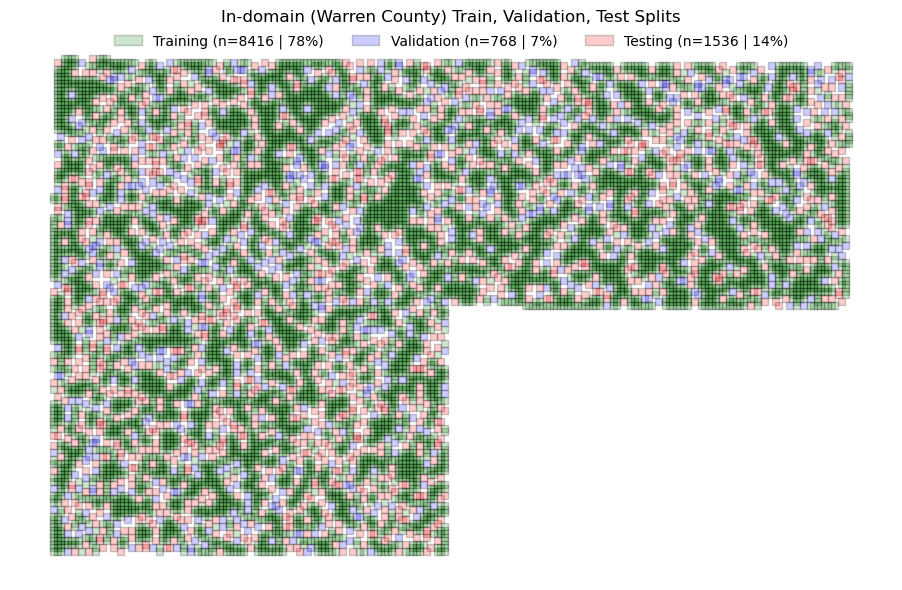

In [4]:
#############################
# Visualize Selected Patches
#############################

fig, ax = plt.subplots(figsize=(10,6))


##### plot patch splits...
gdf_train.plot(ax=ax, facecolor='green', edgecolor='k', linewidth=1, alpha=0.2, label='Training')
gdf_val.plot(ax=ax, facecolor='blue', edgecolor='k', linewidth=1, alpha=0.2, label='Validation')
gdf_test.plot(ax=ax, facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label='Testing')


##### legend...
# count information
total_patches = len(gdf_train) + len(gdf_val) + len(gdf_test)
train_percent = len(gdf_train) / total_patches * 100
val_percent = len(gdf_val) / total_patches * 100
test_percent = len(gdf_test) / total_patches * 100

# legend labels
train_subtitle = f"Training (n={len(gdf_train)} | {int(train_percent)}%)"
val_subtitle = f"Validation (n={len(gdf_val)} | {int(val_percent)}%)"
test_subtitle = f"Testing (n={len(gdf_test)} | {int(test_percent)}%)"

# legend patches
train_patch = Patch(facecolor='green', edgecolor='k', linewidth=1, alpha=0.2, label=train_subtitle)
val_patch = Patch(facecolor='blue', edgecolor='k', linewidth=1, alpha=0.2, label=val_subtitle)
test_patch = Patch(facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label=test_subtitle)
ax.legend(handles=[train_patch, val_patch, test_patch], loc='center', bbox_to_anchor=(0.5, 0.98), frameon=False, ncols=3)


##### title, axis, and save...
ax.set_title('In-domain (Warren County) Train, Validation, Test Splits')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{SPLIT_DIR}/{STR_VERSION}_indomain_splits.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## *Cross-domain (Hardin County)*

In [5]:
##############################
# Test Set from Hardin County
##############################

# list of paths to cross-domain patch GeoJSONs
crossdomain_patch_paths = [glob.glob(os.path.join(d, '*patches*.geojson'))[0] for d in crossdomain_dirs]


##### read patches GeoJSONs into single geodataframe
gdf_list = [gpd.read_file(p) for p in crossdomain_patch_paths]
gdf = pd.concat(gdf_list, ignore_index=True)


##### select test set
gdf_test_cross, _ = select_indpendent_patches(gdf, test_size, seed=patch_seed)


##### save training, validation, & testing patches
gdf_test_cross.to_file(f"{SPLIT_DIR}/{STR_VERSION}_cross.geojson", driver='GeoJSON')

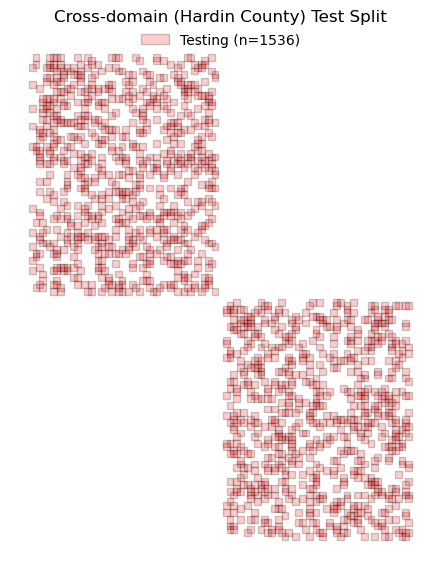

In [7]:
#############################
# Visualize Selected Patches
#############################

fig, ax = plt.subplots(figsize=(8,6))

##### plot cross-domain test split...
gdf_test_cross.plot(ax=ax, facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label='Testing')

##### legend...
test_subtitle = f"Testing (n={len(gdf_test_cross)})"                                              # legend label
test_patch = Patch(facecolor='red', edgecolor='k', linewidth=1, alpha=0.2, label=test_subtitle)   # legend patch
ax.legend(handles=[test_patch], loc='center', bbox_to_anchor=(0.5, 0.98), frameon=False)          # add legend to plot

##### title, axis, and save...
ax.set_title('Cross-domain (Hardin County) Test Split')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{SPLIT_DIR}/{STR_VERSION}_crossdomain_split.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## *Class Distributions*

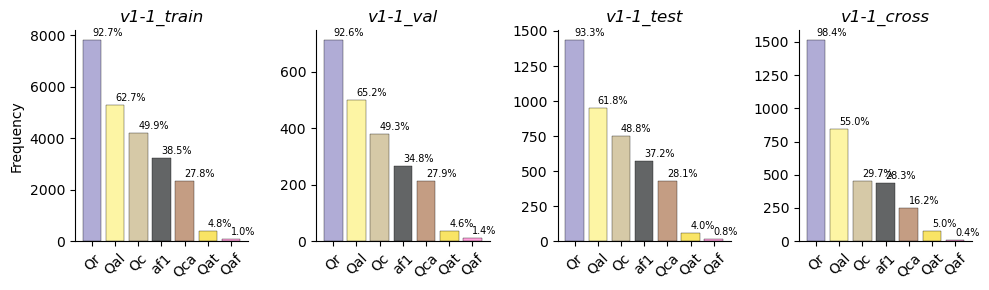

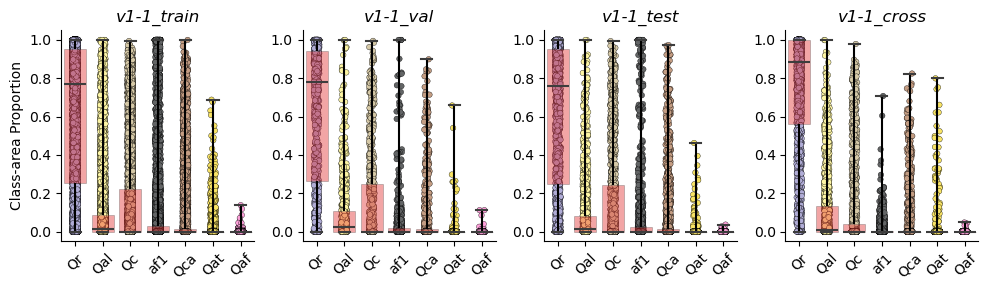

In [ ]:
#########################
# Plot Bar Distributions
#########################

# paths to split GeoJSONs
split_paths = [f"{SPLIT_DIR}/{STR_VERSION}_train.geojson", 
               f"{SPLIT_DIR}/{STR_VERSION}_val.geojson", 
               f"{SPLIT_DIR}/{STR_VERSION}_test.geojson", 
               f"{SPLIT_DIR}/{STR_VERSION}_cross.geojson"]

# # path to class area proportions
# areas_path = f"{DATASET_DIR}/{GLOBAL_AREAS_BASE}"


##### get information for plotting...
areas = pd.read_csv(GLOBAL_AREAS_PATH)
split_dict = {}
order = []
for path in split_paths:

    # get split name...
    name = os.path.basename(path)
    name = os.path.splitext(name)[0]

    # get patch_ids of split
    ids = gpd.read_file(path, ignore_geometry=True)['patch_id']

    # get areas for each patch in split
    split = areas.merge(ids, how='inner', on='patch_id')

    # get order to plot in descending frequency
    order = (split[split.columns[1:]] > 0).sum(axis=0).sort_values(ascending=False)

    # save information to dict...
    split_dict[name] = {}
    split_dict[name]['ids'] = split['patch_id'].to_list()
    split_dict[name]['areas'] = split[split.columns[1:]]
    split_dict[name]['order'] = order


##### plot class distributions of splits...
fig1, ax1 = plt.subplots(ncols=4, figsize=(10,3))   # class counts
fig2, ax2 = plt.subplots(ncols=4, figsize=(10,3))   # class area per patch proportions


for idx, split_name in enumerate(split_dict.keys()):
    ids = split_dict[split_name]['ids']
    areas = split_dict[split_name]['areas']
    order = split_dict[split_name]['order']
    percent = order.values / len(areas) * 100

    # get standardized class colors (global variable from utils)
    colors = [SG_COLORS[unit] for unit in order.index] 

    # frequency
    ax1[idx].bar(x=order.index, height=order.values, lw=0.25, edgecolor='k', facecolor=colors)

    for k in range(0, len(percent)):
        s = str(round(percent[k], 1)) + '%'
        max = order.values.max()
        ax1[idx].text(x=order.index[k], y=order.values[k] + max*0.02, s=s, fontsize=7, rotation=0)


    # class-area proportions...
    sns.stripplot(data=areas[order.index], ax=ax2[idx], jitter=True, palette=colors, edgecolor='k', linewidth=0.25, size=4, zorder=1)
    sns.boxplot(data=areas[order.index], ax=ax2[idx], color='red', whis=(0,100), linewidth=1.5, zorder=2, boxprops={'alpha':0.4, 'lw':0.5}, whiskerprops={'lw':1.5, 'color':'k'}, capprops={'lw':1.5})

    ax1[idx].set_title(split_name, style='italic')
    ax1[idx].spines['top'].set_visible(False)
    ax1[idx].spines['right'].set_visible(False)
    ax1[idx].set_xticks(ax1[idx].get_xticks())
    ax1[idx].set_xticklabels(ax1[idx].get_xticklabels(), rotation=45)

    ax2[idx].set_title(split_name, style='italic')
    ax2[idx].spines['top'].set_visible(False)
    ax2[idx].spines['right'].set_visible(False)
    ax2[idx].set_xticks(ax2[idx].get_xticks())
    ax2[idx].set_xticklabels(ax2[idx].get_xticklabels(), rotation=45)

ax1[0].set_ylabel('Frequency')
ax2[0].set_ylabel('Class-area Proportion')

fig1.tight_layout()
fig2.tight_layout()

fig1.savefig(f"{SPLIT_DIR}/{STR_VERSION}_split_frequency.png", dpi=300, bbox_inches='tight', pad_inches=0)
fig2.savefig(f"{SPLIT_DIR}/{STR_VERSION}_split_areas.png", dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()

## *Training Normalization Stats*

In [4]:
#######################################################
# Calculate Normalization Stats for Training Dataset
#######################################################

# get list of training set patch IDs
train_ids = gpd.read_file(f"{SPLIT_DIR}/{STR_VERSION}_train.geojson")['patch_id'].to_list()

# calculate mean & sample var/sd
df_stats = calculate_dataset_stats(data_dir=indomain_dirs[0], patch_ids=train_ids)

# save as csv
df_stats.to_csv(f"{SPLIT_DIR}/{STR_VERSION}_stats.csv", index=True)

# display df head
df_stats.head()

,mean,sd
dem.tif,578.669434,74.117157
aerialr.tif,81.967148,36.932526
aerialg.tif,81.844147,31.426735
aerialb.tif,74.155853,27.584213
aerialnir.tif,104.604042,34.800819
